#GPU Verification

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


#Install Libraries

In [2]:
!pip install -q torch torchvision torchaudio
!pip install -q scikit-learn seaborn pandas matplotlib pillow tqdm

#Clone the dataset

In [4]:
!git clone --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163219, done.
remote: Counting objects: 100% (163219/163219), done.
remote: Compressing objects: 100% (163125/163125), done.
remote: Total 163219 (delta 93), reused 163215 (delta 93), pack-reused 0 (from 0)
Receiving objects: 100% (163219/163219), 2.00 GiB | 19.58 MiB/s, done.
Resolving deltas: 100% (93/93), done.
Updating files: 100% (182404/182404), done.


In [5]:
# check dataset installed proper or not

import os

DATASET_PATH = "/content/PlantVillage-Dataset"

print("Dataset exists:", os.path.exists(DATASET_PATH))

print("\nDataset contents:")
for item in os.listdir(DATASET_PATH):
    print(item)

Dataset exists: True

Dataset contents:
generated_for_paper
.git
generate_mapstring.py
utils
generate_lmdb.sh
README.md
raw
CITATION.cff
leaf-map.json
logs
scripts
.gitignore
data_distribution_for_SVM
README_HF.md
plant_village.py
leaf_grouping
generate_data_for_SVM.py


#Locate Color Images

In [6]:
COLOR_PATH = "/content/PlantVillage-Dataset/raw/color"

print("Color dataset exists:", os.path.exists(COLOR_PATH))

Color dataset exists: True


#Inspect PlantVillage Classes

In [7]:
classes = sorted([
    d for d in os.listdir(COLOR_PATH)
    if os.path.isdir(os.path.join(COLOR_PATH, d))
])

print("Number of classes:", len(classes))

print("\nClasses:")
for i, cls in enumerate(classes):
    print(f"{i:02d} -> {cls}")

Number of classes: 38

Classes:
00 -> Apple___Apple_scab
01 -> Apple___Black_rot
02 -> Apple___Cedar_apple_rust
03 -> Apple___healthy
04 -> Blueberry___healthy
05 -> Cherry_(including_sour)___Powdery_mildew
06 -> Cherry_(including_sour)___healthy
07 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
08 -> Corn_(maize)___Common_rust_
09 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_blig

#Inspect Image Counts

In [8]:
class_counts = {}

for cls in classes:

    folder = os.path.join(COLOR_PATH, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[cls] = len(images)

print("Total images:", sum(class_counts.values()))

print("\nImages per class:")

for cls, count in class_counts.items():
    print(f"{cls:50s} {count}")

Total images: 54305

Images per class:
Apple___Apple_scab                                 630
Apple___Black_rot                                  621
Apple___Cedar_apple_rust                           275
Apple___healthy                                    1645
Blueberry___healthy                                1502
Cherry_(including_sour)___Powdery_mildew           1052
Cherry_(including_sour)___healthy                  854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 513
Corn_(maize)___Common_rust_                        1192
Corn_(maize)___Northern_Leaf_Blight                985
Corn_(maize)___healthy                             1162
Grape___Black_rot                                  1180
Grape___Esca_(Black_Measles)                       1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)         1076
Grape___healthy                                    423
Orange___Haunglongbing_(Citrus_greening)           5507
Peach___Bacterial_spot                             2297
Peach___healthy 

#Display Sample Images

Class: Squash___Powdery_mildew
Image: 4db5164e-d91e-4f1f-8686-591596406758___MD_Powd.M 0800.JPG
Image size: (256, 256)


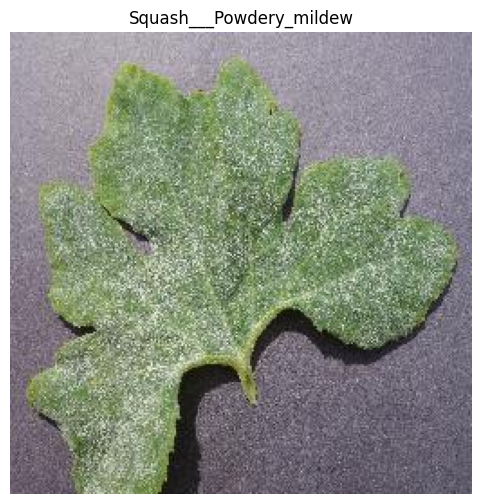

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

sample_class = random.choice(classes)

folder = os.path.join(COLOR_PATH, sample_class)

image_files = [
    f for f in os.listdir(folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample_file = random.choice(image_files)

image_path = os.path.join(folder, sample_file)

image = Image.open(image_path).convert("RGB")

print("Class:", sample_class)
print("Image:", sample_file)
print("Image size:", image.size)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(sample_class)
plt.show()

#Display PlantVillage Class List

In [10]:
# CELL 8 — Display PlantVillage Class List

print("Total PlantVillage classes:", len(classes))
print("\nPlantVillage Classes:\n")

for i, cls in enumerate(classes):
    print(f"{i:02d} -> {cls}")

Total PlantVillage classes: 38

PlantVillage Classes:

00 -> Apple___Apple_scab
01 -> Apple___Black_rot
02 -> Apple___Cedar_apple_rust
03 -> Apple___healthy
04 -> Blueberry___healthy
05 -> Cherry_(including_sour)___Powdery_mildew
06 -> Cherry_(including_sour)___healthy
07 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
08 -> Corn_(maize)___Common_rust_
09 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
3

#Identify SIH-Relevant PlantVillage Classes

In [11]:
# CELL 9 — Check SIH Example Classes in PlantVillage

keywords = [
    "Tomato",
    "Potato",
    "Corn",
    "Apple",
    "Grape",
    "Pepper"
]

print("Relevant PlantVillage classes:\n")

for cls in classes:
    if any(keyword.lower() in cls.lower() for keyword in keywords):
        print(cls)

Relevant PlantVillage classes:

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


#Organize Candidate Classes

In [12]:
# CELL 10 — Organize Candidate Classes by Crop

candidate_classes = []

for cls in classes:
    if any(keyword.lower() in cls.lower() for keyword in keywords):
        candidate_classes.append(cls)

print("Candidate PlantVillage Classes by Crop")
print("=" * 70)

for crop in ["Apple", "Corn_(maize)", "Grape", "Pepper,_bell", "Potato", "Tomato"]:

    print(f"\n{crop}")
    print("-" * 70)

    crop_classes = [
        cls for cls in candidate_classes
        if cls.startswith(crop + "___")
    ]

    for cls in crop_classes:
        label = cls.split("___", 1)[1]

        if label.lower() == "healthy":
            category = "Healthy"
        else:
            category = "Disease"

        print(f"  {category:8} -> {label}")

Candidate PlantVillage Classes by Crop

Apple
----------------------------------------------------------------------
  Disease  -> Apple_scab
  Disease  -> Black_rot
  Disease  -> Cedar_apple_rust
  Healthy  -> healthy

Corn_(maize)
----------------------------------------------------------------------
  Disease  -> Cercospora_leaf_spot Gray_leaf_spot
  Disease  -> Common_rust_
  Disease  -> Northern_Leaf_Blight
  Healthy  -> healthy

Grape
----------------------------------------------------------------------
  Disease  -> Black_rot
  Disease  -> Esca_(Black_Measles)
  Disease  -> Leaf_blight_(Isariopsis_Leaf_Spot)
  Healthy  -> healthy

Pepper,_bell
----------------------------------------------------------------------
  Disease  -> Bacterial_spot
  Healthy  -> healthy

Potato
----------------------------------------------------------------------
  Disease  -> Early_blight
  Disease  -> Late_blight
  Healthy  -> healthy

Tomato
--------------------------------------------------------

#Standard format for class labels

In [13]:
# CELL 11 — Prepare Standard Class Format

# SIH standard format:
# Crop___Disease
# Example:
# Tomato___Early_blight
# Potato___Late_blight
# Apple___Black_rot
# Tomato___healthy

standard_candidate_classes = sorted(candidate_classes)

print("SIH Standard Class Format")
print("=" * 70)

for i, cls in enumerate(standard_candidate_classes):
    crop, disease = cls.split("___", 1)
    print(f"{i:02d} -> {crop}___{disease}")

print("\nTotal candidate classes:", len(standard_candidate_classes))

SIH Standard Class Format
00 -> Apple___Apple_scab
01 -> Apple___Black_rot
02 -> Apple___Cedar_apple_rust
03 -> Apple___healthy
04 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
05 -> Corn_(maize)___Common_rust_
06 -> Corn_(maize)___Northern_Leaf_Blight
07 -> Corn_(maize)___healthy
08 -> Grape___Black_rot
09 -> Grape___Esca_(Black_Measles)
10 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
11 -> Grape___healthy
12 -> Pepper,_bell___Bacterial_spot
13 -> Pepper,_bell___healthy
14 -> Potato___Early_blight
15 -> Potato___Late_blight
16 -> Potato___healthy
17 -> Tomato___Bacterial_spot
18 -> Tomato___Early_blight
19 -> Tomato___Late_blight
20 -> Tomato___Leaf_Mold
21 -> Tomato___Septoria_leaf_spot
22 -> Tomato___Spider_mites Two-spotted_spider_mite
23 -> Tomato___Target_Spot
24 -> Tomato___Tomato_Yellow_Leaf_Curl_Virus
25 -> Tomato___Tomato_mosaic_virus
26 -> Tomato___healthy

Total candidate classes: 27


#Create Dataset Metadata

In [14]:
# CELL 12 — Create Dataset Metadata

import os
import hashlib
import pandas as pd
from PIL import Image
from tqdm import tqdm

metadata = []

for cls in standard_candidate_classes:

    class_path = os.path.join(COLOR_PATH, cls)

    # Split standard label
    crop, disease = cls.split("___", 1)

    for filename in tqdm(
        os.listdir(class_path),
        desc=f"Processing {cls}"
    ):

        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(class_path, filename)

        # File hash
        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        # Image validation
        try:
            with Image.open(image_path) as img:
                width, height = img.size
                image_mode = img.mode
                quality_valid = True

        except Exception:
            width = None
            height = None
            image_mode = None
            quality_valid = False

        # Store metadata
        metadata.append({
            "file_path": image_path,

            # Original PlantVillage label
            "original_label": cls,

            # Standard SIH-style label
            "standard_label": f"{crop}___{disease}",

            "crop": crop,
            "disease": disease,

            "width": width,
            "height": height,
            "image_mode": image_mode,

            "file_hash": file_hash,
            "quality_valid": quality_valid
        })


# Create DataFrame
metadata_df = pd.DataFrame(metadata)

print("\nMetadata created successfully!")
print("=" * 70)

print("Total images:", len(metadata_df))
print("Total classes:", metadata_df["standard_label"].nunique())
print("Total columns:", len(metadata_df.columns))

print("\nStandard labels:")
for label in sorted(metadata_df["standard_label"].unique()):
    print(" -", label)

print("\nFirst 5 records:")
display(metadata_df.head())

Processing Apple___healthy: 100%|██████████| 1645/1645 [00:00<00:00, 7646.71it/s]
Processing Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 100%|██████████| 513/513 [00:00<00:00, 7968.68it/s]
Processing Grape___Esca_(Black_Measles): 100%|██████████| 1383/1383 [00:00<00:00, 7139.77it/s]
Processing Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 100%|██████████| 1076/1076 [00:00<00:00, 7868.46it/s]
Processing Tomato___Septoria_leaf_spot: 100%|██████████| 1771/1771 [00:00<00:00, 7870.71it/s]
Processing Tomato___Spider_mites Two-spotted_spider_mite: 100%|██████████| 1676/1676 [00:00<00:00, 7122.59it/s]
Processing Tomato___Target_Spot: 100%|██████████| 1404/1404 [00:00<00:00, 7657.74it/s]
Processing Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100%|██████████| 5357/5357 [00:00<00:00, 8555.15it/s]
Processing Tomato___healthy: 100%|██████████| 1591/1591 [00:00<00:00, 6637.59it/s]



Metadata created successfully!
Total images: 33872
Total classes: 27
Total columns: 10

Standard labels:
 - Apple___Apple_scab
 - Apple___Black_rot
 - Apple___Cedar_apple_rust
 - Apple___healthy
 - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 - Corn_(maize)___Common_rust_
 - Corn_(maize)___Northern_Leaf_Blight
 - Corn_(maize)___healthy
 - Grape___Black_rot
 - Grape___Esca_(Black_Measles)
 - Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
 - Grape___healthy
 - Pepper,_bell___Bacterial_spot
 - Pepper,_bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Tomato___Bacterial_spot
 - Tomato___Early_blight
 - Tomato___Late_blight
 - Tomato___Leaf_Mold
 - Tomato___Septoria_leaf_spot
 - Tomato___Spider_mites Two-spotted_spider_mite
 - Tomato___Target_Spot
 - Tomato___Tomato_Yellow_Leaf_Curl_Virus
 - Tomato___Tomato_mosaic_virus
 - Tomato___healthy

First 5 records:


,file_path,original_label,standard_label,crop,disease,width,height,image_mode,file_hash,quality_valid
0,/content/PlantVillage-Dataset/raw/color/Apple_...,Apple___Apple_scab,Apple___Apple_scab,Apple,Apple_scab,256,256,RGB,2a1d5dc705e01f3224ee5d088af674c4,True
1,/content/PlantVillage-Dataset/raw/color/Apple_...,Apple___Apple_scab,Apple___Apple_scab,Apple,Apple_scab,256,256,RGB,1b3b1592318bb98a3a8fad8496576e65,True
2,/content/PlantVillage-Dataset/raw/color/Apple_...,Apple___Apple_scab,Apple___Apple_scab,Apple,Apple_scab,256,256,RGB,f523e7f0bcc6686962daf6e0f68a9fe9,True
3,/content/PlantVillage-Dataset/raw/color/Apple_...,Apple___Apple_scab,Apple___Apple_scab,Apple,Apple_scab,256,256,RGB,5e2df031f26a1e42c31ae7a3013398f6,True
4,/content/PlantVillage-Dataset/raw/color/Apple_...,Apple___Apple_scab,Apple___Apple_scab,Apple,Apple_scab,256,256,RGB,ec94f382f1762ad4c98d3f639e5f4856,True


#Check Dataset Quality

In [15]:
# CELL 13 — Check Dataset Quality

print("Dataset Quality Check")
print("=" * 70)

# Total images
total_images = len(metadata_df)

# Valid / invalid images
valid_images = metadata_df["quality_valid"].sum()
invalid_images = total_images - valid_images

print(f"Total images   : {total_images}")
print(f"Valid images   : {valid_images}")
print(f"Invalid images : {invalid_images}")

# Check missing values
print("\nMissing values:")
print(metadata_df.isnull().sum())

# Check image dimensions
print("\nImage dimensions:")
print(metadata_df[["width", "height"]].describe())

# Check duplicate file hashes
duplicate_hashes = metadata_df[
    metadata_df.duplicated("file_hash", keep=False)
].sort_values("file_hash")

print("\nDuplicate files detected:", len(duplicate_hashes))

if len(duplicate_hashes) > 0:
    display(duplicate_hashes[[
        "file_path",
        "standard_label",
        "file_hash"
    ]].head(20))
else:
    print("No duplicate files found.")

Dataset Quality Check
Total images   : 33872
Valid images   : 33872
Invalid images : 0

Missing values:
file_path         0
original_label    0
standard_label    0
crop              0
disease           0
width             0
height            0
image_mode        0
file_hash         0
quality_valid     0
dtype: int64

Image dimensions:
         width   height
count  33872.0  33872.0
mean     256.0    256.0
std        0.0      0.0
min      256.0    256.0
25%      256.0    256.0
50%      256.0    256.0
75%      256.0    256.0
max      256.0    256.0

Duplicate files detected: 42


,file_path,standard_label,file_hash
19663,/content/PlantVillage-Dataset/raw/color/Tomato...,Tomato___Late_blight,0e0dcd876f5b32cac9da836b2e783d91
20627,/content/PlantVillage-Dataset/raw/color/Tomato...,Tomato___Late_blight,0e0dcd876f5b32cac9da836b2e783d91
1608,/content/PlantVillage-Dataset/raw/color/Apple_...,Apple___healthy,161940bd6e73cf648974cc7213cffb8f
2048,/content/PlantVillage-Dataset/raw/color/Apple_...,Apple___healthy,161940bd6e73cf648974cc7213cffb8f
20160,/content/PlantVillage-Dataset/raw/color/Tomato...,Tomato___Late_blight,1d87a50fa691cef6f476b20bb48cfaf8
19216,/content/PlantVillage-Dataset/raw/color/Tomato...,Tomato___Late_blight,1d87a50fa691cef6f476b20bb48cfaf8
33425,/content/PlantVillage-Dataset/raw/color/Tomato...,Tomato___healthy,2e53ad1ec3f810e2ff4c83400dc69ec9
33003,/content/PlantVillage-Dataset/raw/color/Tomato...,Tomato___healthy,2e53ad1ec3f810e2ff4c83400dc69ec9
33142,/content/PlantVillage-Dataset/raw/color/Tomato...,Tomato___healthy,32cb22521edc69a5503a6749446dd522
33190,/content/PlantVillage-Dataset/raw/color/Tomato...,Tomato___healthy,32cb22521edc69a5503a6749446dd522


#Remove Exact Duplicates

In [16]:
# CELL 14 — Remove Exact Duplicate Images

print("Removing exact duplicate images...")
print("=" * 70)

before_count = len(metadata_df)

# Keep the first occurrence of each file hash
metadata_df_clean = metadata_df.drop_duplicates(
    subset="file_hash",
    keep="first"
).reset_index(drop=True)

after_count = len(metadata_df_clean)

removed_count = before_count - after_count

print(f"Images before removing duplicates : {before_count}")
print(f"Duplicate images removed          : {removed_count}")
print(f"Images after cleaning             : {after_count}")

print("\nClass distribution after cleaning:")
class_distribution = (
    metadata_df_clean["standard_label"]
    .value_counts()
    .sort_index()
)

display(class_distribution.to_frame("image_count"))

Removing exact duplicate images...
Images before removing duplicates : 33872
Duplicate images removed          : 21
Images after cleaning             : 33851

Class distribution after cleaning:


,image_count
standard_label,
Apple___Apple_scab,630
Apple___Black_rot,621
Apple___Cedar_apple_rust,275
Apple___healthy,1638
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,513
Corn_(maize)___Common_rust_,1192
Corn_(maize)___Northern_Leaf_Blight,985
Corn_(maize)___healthy,1162
Grape___Black_rot,1180


#Visualize Class Distribution

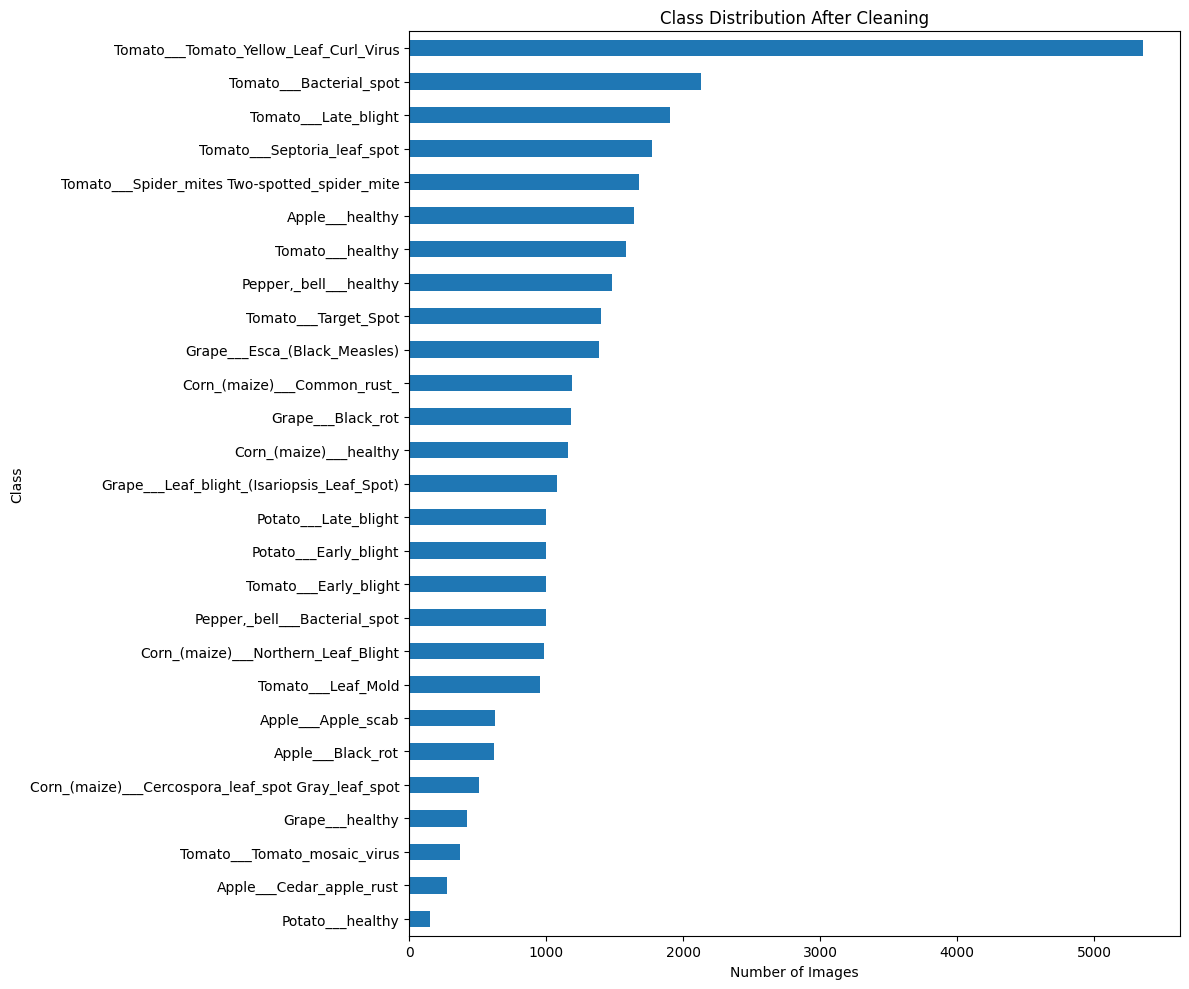

Minimum class size: 152
Maximum class size: 5357
Number of classes: 27


In [17]:
# CELL 15 — Visualize Class Distribution

import matplotlib.pyplot as plt

class_counts_clean = (
    metadata_df_clean["standard_label"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 10))

class_counts_clean.plot(kind="barh")

plt.title("Class Distribution After Cleaning")
plt.xlabel("Number of Images")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

print("Minimum class size:", class_counts_clean.min())
print("Maximum class size:", class_counts_clean.max())
print("Number of classes:", len(class_counts_clean))


#Stratified Train/Validation Split

In [18]:
# CELL 16 — Stratified Train/Validation Split

from sklearn.model_selection import train_test_split

# Use cleaned dataset
df = metadata_df_clean.copy()

# Stratified split: keeps class proportions similar
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["standard_label"]
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Dataset Split")
print("=" * 70)

print(f"Total images     : {len(df)}")
print(f"Training images  : {len(train_df)}")
print(f"Validation images: {len(val_df)}")

print("\nNumber of classes:")
print("Training   :", train_df["standard_label"].nunique())
print("Validation :", val_df["standard_label"].nunique())

print("\nTraining class distribution:")
display(
    train_df["standard_label"]
    .value_counts()
    .sort_index()
    .to_frame("train_count")
)

print("\nValidation class distribution:")
display(
    val_df["standard_label"]
    .value_counts()
    .sort_index()
    .to_frame("val_count")
)

Dataset Split
Total images     : 33851
Training images  : 27080
Validation images: 6771

Number of classes:
Training   : 27
Validation : 27

Training class distribution:


,train_count
standard_label,
Apple___Apple_scab,504
Apple___Black_rot,497
Apple___Cedar_apple_rust,220
Apple___healthy,1310
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,410
Corn_(maize)___Common_rust_,954
Corn_(maize)___Northern_Leaf_Blight,788
Corn_(maize)___healthy,930
Grape___Black_rot,944



Validation class distribution:


,val_count
standard_label,
Apple___Apple_scab,126
Apple___Black_rot,124
Apple___Cedar_apple_rust,55
Apple___healthy,328
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,103
Corn_(maize)___Common_rust_,238
Corn_(maize)___Northern_Leaf_Blight,197
Corn_(maize)___healthy,232
Grape___Black_rot,236


#Image Preprocessing & Augmentation

In [20]:
# CELL 17 — Image Preprocessing & Augmentation

from torchvision import transforms

IMAGE_SIZE = 224

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Data augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation transformations
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing configured successfully!")
print("Image size:", IMAGE_SIZE)
print("Training augmentation: Enabled")
print("Validation augmentation: Disabled")

Image preprocessing configured successfully!
Image size: 224
Training augmentation: Enabled
Validation augmentation: Disabled


#Create PyTorch Dataset

In [21]:
# CELL 18 — Create PyTorch Dataset

import torch
from torch.utils.data import Dataset
from PIL import Image

# Create label mapping
class_names = sorted(train_df["standard_label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Number of classes:", len(class_names))

class PlantDiseaseDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Load image
        image = Image.open(row["file_path"]).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert class name to numerical label
        label = class_to_idx[row["standard_label"]]

        return image, label


# Create datasets
train_dataset = PlantDiseaseDataset(
    train_df,
    transform=train_transform
)

val_dataset = PlantDiseaseDataset(
    val_df,
    transform=val_transform
)

print("\nDatasets created successfully!")
print("Training dataset :", len(train_dataset))
print("Validation dataset:", len(val_dataset))

print("\nExample:")
sample_image, sample_label = train_dataset[0]

print("Image tensor shape:", sample_image.shape)
print("Label index:", sample_label)
print("Label name:", idx_to_class[sample_label])

Number of classes: 27

Datasets created successfully!
Training dataset : 27080
Validation dataset: 6771

Example:
Image tensor shape: torch.Size([3, 224, 224])
Label index: 4
Label name: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot


#Create DataLoaders

In [22]:
# CELL 19 — Create DataLoaders

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully!")
print("=" * 70)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

# Test one batch
images, labels = next(iter(train_loader))

print("\nTest batch:")
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

DataLoaders created successfully!
Batch size: 32
Training batches: 847
Validation batches: 212

Test batch:
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


#Load Pretrained EfficientNet-B0

In [23]:
# CELL 20 — Load Pretrained EfficientNet-B0

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Load pretrained EfficientNet-B0
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

# Number of classes
num_classes = len(class_names)

# Replace the final classification layer
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    num_classes
)

# Move model to GPU/CPU
model = model.to(device)

print("\nModel:", "EfficientNet-B0")
print("Pretrained weights: ImageNet")
print("Number of output classes:", num_classes)
print("Model loaded successfully!")

Using device: cuda
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]



Model: EfficientNet-B0
Pretrained weights: ImageNet
Number of output classes: 27
Model loaded successfully!


#Configure Loss Function and Optimizer

In [24]:
# CELL 21 — Configure Loss Function and Optimizer

import torch
import torch.nn as nn
import torch.optim as optim

# Count images for each class in the training set
train_class_counts = (
    train_df["standard_label"]
    .value_counts()
    .reindex(class_names)
)

# Calculate class weights
class_weights = len(train_df) / (
    len(class_names) * train_class_counts.values
)

# Convert to PyTorch tensor
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

# Weighted Cross Entropy Loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# AdamW optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print("Loss function and optimizer configured!")
print("=" * 70)

print("Loss function : Weighted Cross Entropy")
print("Optimizer     : AdamW")
print("Learning rate : 0.0001")
print("Weight decay  : 0.0001")

print("\nClass weights:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {class_weights[i].item():.4f}")

Loss function and optimizer configured!
Loss function : Weighted Cross Entropy
Optimizer     : AdamW
Learning rate : 0.0001
Weight decay  : 0.0001

Class weights:
Apple___Apple_scab: 1.9900
Apple___Black_rot: 2.0180
Apple___Cedar_apple_rust: 4.5589
Apple___healthy: 0.7656
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 2.4463
Corn_(maize)___Common_rust_: 1.0513
Corn_(maize)___Northern_Leaf_Blight: 1.2728
Corn_(maize)___healthy: 1.0785
Grape___Black_rot: 1.0625
Grape___Esca_(Black_Measles): 0.9068
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1.1649
Grape___healthy: 2.9673
Pepper,_bell___Bacterial_spot: 1.2568
Pepper,_bell___healthy: 0.8485
Potato___Early_blight: 1.2537
Potato___Late_blight: 1.2537
Potato___healthy: 8.2210
Tomato___Bacterial_spot: 0.5896
Tomato___Early_blight: 1.2537
Tomato___Late_blight: 0.6594
Tomato___Leaf_Mold: 1.3162
Tomato___Septoria_leaf_spot: 0.7078
Tomato___Spider_mites Two-spotted_spider_mite: 0.7479
Tomato___Target_Spot: 0.8931
Tomato___Tomato_Yellow_Leaf_C

#Training & Validation Functions

In [25]:
# CELL 22 — Training & Validation Functions

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import numpy as np

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    progress_bar = tqdm(loader, desc="Training")

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Store statistics
        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    epoch_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    epoch_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_f1,
        epoch_precision,
        epoch_recall
    )


def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        progress_bar = tqdm(loader, desc="Validation")

        for images, labels in progress_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    epoch_loss = running_loss / len(loader.dataset)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    epoch_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    epoch_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_f1,
        epoch_precision,
        epoch_recall
    )


print("Training and validation functions created successfully!")
print("\nMetrics:")
print("• Loss")
print("• Accuracy")
print("• Macro-F1")
print("• Macro Precision")
print("• Macro Recall")

Training and validation functions created successfully!

Metrics:
• Loss
• Accuracy
• Macro-F1
• Macro Precision
• Macro Recall


#Train EfficientNet-B0

In [26]:
# CELL 23 — Train EfficientNet-B0

import copy
import torch

NUM_EPOCHS = 10

best_macro_f1 = 0.0
best_model_state = copy.deepcopy(model.state_dict())

# Store training history
history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "train_precision": [],
    "train_recall": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],
    "val_precision": [],
    "val_recall": []
}

print("Starting training...")
print("=" * 70)

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 70)

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_acc, train_f1, train_precision, train_recall = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_acc, val_f1, val_precision, val_recall = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # Save history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["train_precision"].append(train_precision)
    history["train_recall"].append(train_recall)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)

    # Print results
    print(f"\nTrain Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Train Macro-F1  : {train_f1:.4f}")

    print(f"\nVal Loss        : {val_loss:.4f}")
    print(f"Val Accuracy    : {val_acc:.4f}")
    print(f"Val Macro-F1    : {val_f1:.4f}")
    print(f"Val Precision   : {val_precision:.4f}")
    print(f"Val Recall      : {val_recall:.4f}")

    # Save best model based on Macro-F1
    if val_f1 > best_macro_f1:

        best_macro_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "model_state_dict": best_model_state,
                "class_names": class_names,
                "best_macro_f1": best_macro_f1
            },
            "/content/best_agri_model.pth"
        )

        print("\n✓ Best model saved!")
        print(f"✓ Best Validation Macro-F1: {best_macro_f1:.4f}")


# Restore best model
model.load_state_dict(best_model_state)

print("\n" + "=" * 70)
print("Training completed!")
print(f"Best Validation Macro-F1: {best_macro_f1:.4f}")
print("Best model saved at:")
print("/content/best_agri_model.pth")

Starting training...

Epoch 1/10
----------------------------------------------------------------------


Validation: 100%|██████████| 212/212 [00:23<00:00,  8.87it/s]



Train Loss      : 0.6122
Train Accuracy  : 0.8600
Train Macro-F1  : 0.8435

Val Loss        : 0.0826
Val Accuracy    : 0.9756
Val Macro-F1    : 0.9709
Val Precision   : 0.9714
Val Recall      : 0.9722

✓ Best model saved!
✓ Best Validation Macro-F1: 0.9709

Epoch 2/10
----------------------------------------------------------------------


Validation: 100%|██████████| 212/212 [00:22<00:00,  9.53it/s]



Train Loss      : 0.1009
Train Accuracy  : 0.9678
Train Macro-F1  : 0.9653

Val Loss        : 0.0506
Val Accuracy    : 0.9854
Val Macro-F1    : 0.9797
Val Precision   : 0.9765
Val Recall      : 0.9840

✓ Best model saved!
✓ Best Validation Macro-F1: 0.9797

Epoch 3/10
----------------------------------------------------------------------


...


Train Loss      : 0.0248
Train Accuracy  : 0.9916
Train Macro-F1  : 0.9909

Val Loss        : 0.0416
Val Accuracy    : 0.9926
Val Macro-F1    : 0.9893
Val Precision   : 0.9910
Val Recall      : 0.9886

Epoch 9/10
----------------------------------------------------------------------


Validation: 100%|██████████| 212/212 [00:23<00:00,  8.88it/s]



Train Loss      : 0.0221
Train Accuracy  : 0.9928
Train Macro-F1  : 0.9919

Val Loss        : 0.0334
Val Accuracy    : 0.9936
Val Macro-F1    : 0.9911
Val Precision   : 0.9918
Val Recall      : 0.9907

Epoch 10/10
----------------------------------------------------------------------


Validation: 100%|██████████| 212/212 [00:23<00:00,  8.96it/s]



Train Loss      : 0.0185
Train Accuracy  : 0.9938
Train Macro-F1  : 0.9927

Val Loss        : 0.0224
Val Accuracy    : 0.9957
Val Macro-F1    : 0.9938
Val Precision   : 0.9948
Val Recall      : 0.9930

✓ Best model saved!
✓ Best Validation Macro-F1: 0.9938

Training completed!
Best Validation Macro-F1: 0.9938
Best model saved at:
/content/best_agri_model.pth


#Plot Training Performance

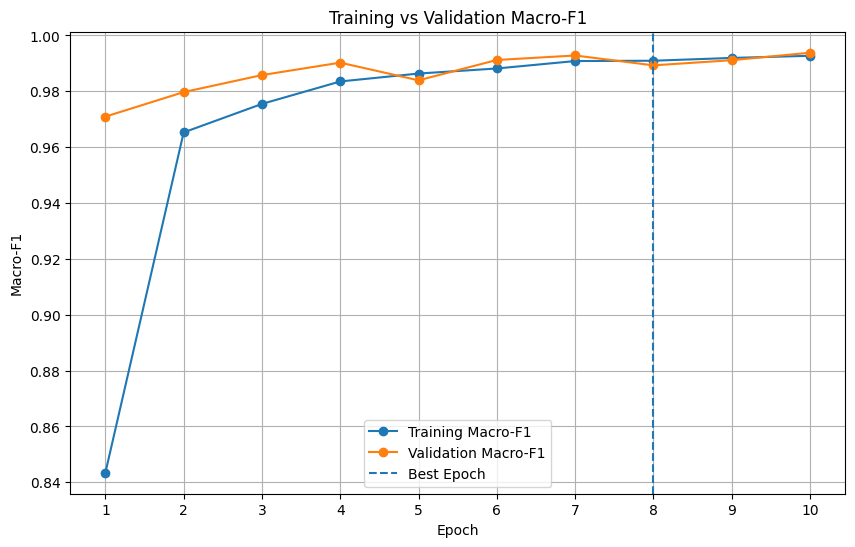

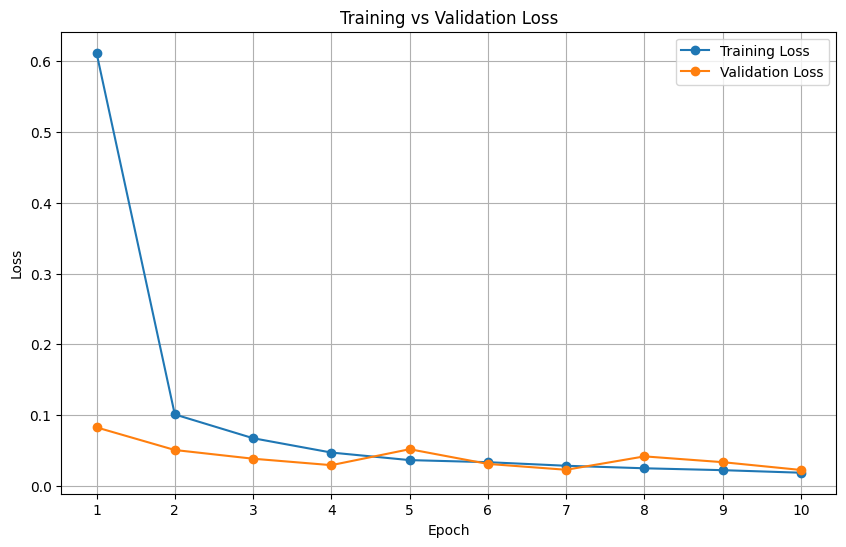

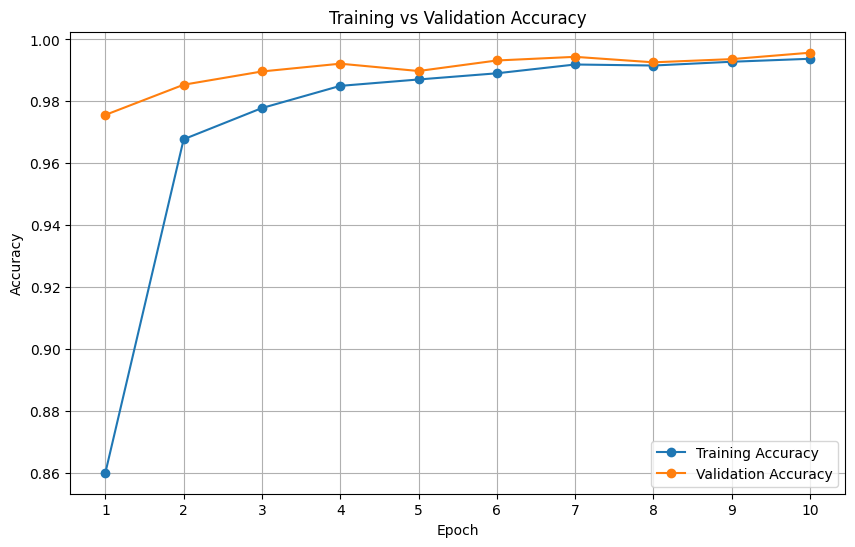

In [27]:
# CELL 24 — Plot Training Performance

import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

# -------------------------
# Macro-F1
# -------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_f1"],
    marker="o",
    label="Training Macro-F1"
)

plt.plot(
    epochs,
    history["val_f1"],
    marker="o",
    label="Validation Macro-F1"
)

plt.axvline(
    x=8,
    linestyle="--",
    label="Best Epoch"
)

plt.title("Training vs Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()


# -------------------------
# Loss
# -------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()


# -------------------------
# Accuracy
# -------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()

#Per-Class Precision, Recall and F1

In [28]:
# CELL 25 — Per-Class Precision, Recall and F1

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import numpy as np

# Use the best model
model.load_state_dict(best_model_state)
model.eval()

all_predictions = []
all_labels = []

print("Running final validation evaluation...")

with torch.no_grad():

    for images, labels in tqdm(val_loader, desc="Evaluating"):

        images = images.to(device, non_blocking=True)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )


# Convert to NumPy arrays
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Classification report
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\nClassification Report")
print("=" * 100)
print(report)

# Overall metrics
macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print("\nOverall Validation Metrics")
print("=" * 70)
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")

Running final validation evaluation...


Evaluating: 100%|██████████| 212/212 [00:22<00:00,  9.39it/s]


Classification Report
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9841    0.9920       126
                                 Apple___Black_rot     1.0000    1.0000    1.0000       124
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        55
                                   Apple___healthy     0.9970    1.0000    0.9985       328
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9579    0.8835    0.9192       103
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       238
               Corn_(maize)___Northern_Leaf_Blight     0.9415    0.9797    0.9602       197
                            Corn_(maize)___healthy     1.0000    1.0000    1.0000       232
                                 Grape___Black_rot     0.9958    1.0000    0.9979       236
                      Grape___Esca_(Black_Measles)     1

#Generate Confusion Matrix

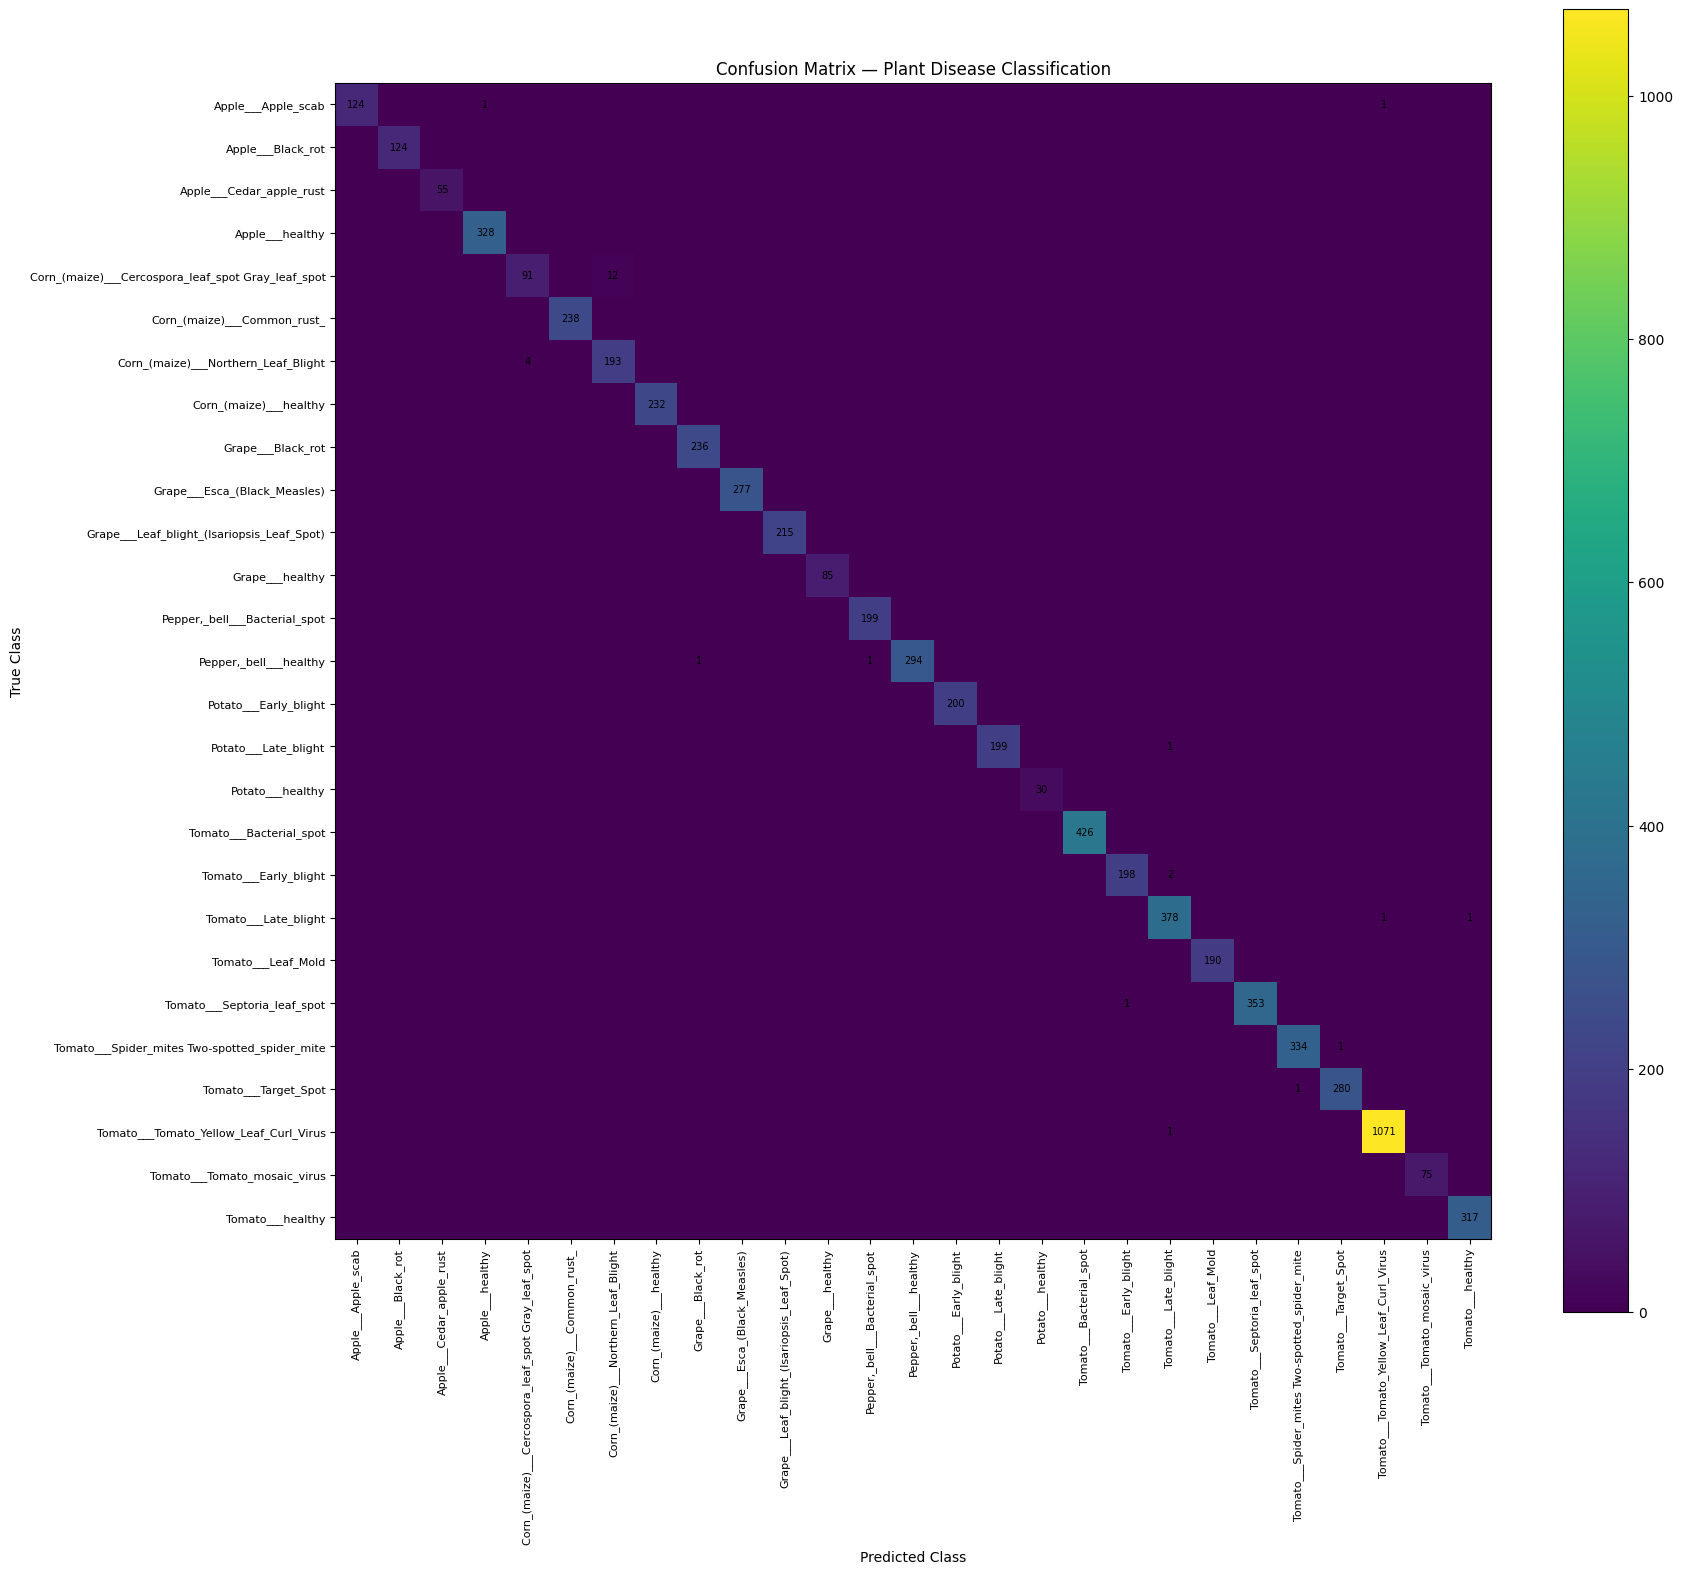

Confusion matrix shape: (27, 27)


In [29]:
# CELL 26 — Generate Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=range(len(class_names))
)

# Plot
plt.figure(figsize=(18, 16))

plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix — Plant Disease Classification")
plt.colorbar()

# Axis labels
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(class_names)),
    class_names,
    fontsize=8
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add values inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm[i, j] > 0:
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=7
            )

plt.tight_layout()
plt.show()

print("Confusion matrix shape:", cm.shape)

#Save Complete Model Package

In [30]:
# CELL 27 — Save Complete Model Package

import torch
import json
import os

# Make sure the best model is loaded
model.load_state_dict(best_model_state)
model.eval()

# Complete model package
model_package = {
    "model_name": "EfficientNet-B0",
    "num_classes": len(class_names),
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "image_size": IMAGE_SIZE,
    "best_macro_f1": best_macro_f1,
    "model_state_dict": model.state_dict()
}

# Save model package
MODEL_PATH = "/content/agri_smart_efficientnet_b0.pth"

torch.save(
    model_package,
    MODEL_PATH
)

print("Model package saved successfully!")
print("=" * 70)
print("Model path:", MODEL_PATH)
print("Model:", model_package["model_name"])
print("Classes:", model_package["num_classes"])
print("Image size:", model_package["image_size"])
print("Best Macro-F1:", model_package["best_macro_f1"])
print("File size: {:.2f} MB".format(
    os.path.getsize(MODEL_PATH) / (1024 * 1024)
))

Model package saved successfully!
Model path: /content/agri_smart_efficientnet_b0.pth
Model: EfficientNet-B0
Classes: 27
Image size: 224
Best Macro-F1: 0.993815847758384
File size: 15.71 MB


#Create Prediction Function

In [31]:
# CELL 28 — Create Prediction Function

import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Load saved model package
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

# Rebuild model
inference_model = efficientnet_b0(weights=None)

in_features = inference_model.classifier[1].in_features
inference_model.classifier[1] = nn.Linear(
    in_features,
    checkpoint["num_classes"]
)

inference_model.load_state_dict(checkpoint["model_state_dict"])
inference_model = inference_model.to(device)
inference_model.eval()

# Class information
inference_class_names = checkpoint["class_names"]
inference_image_size = checkpoint["image_size"]

# Same preprocessing used for validation
inference_transform = transforms.Compose([
    transforms.Resize((inference_image_size, inference_image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def predict(image_path):
    """
    Predict crop disease from a leaf image.

    Parameters:
        image_path (str): Path to input image

    Returns:
        predicted_class (str)
        confidence (float)
    """

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    input_tensor = inference_transform(image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted_idx = torch.max(probabilities, dim=1)

    predicted_class = inference_class_names[predicted_idx.item()]
    confidence = confidence.item()

    # Display result
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.show()

    return predicted_class, confidence


print("Prediction function created successfully!")
print("Function: predict(image_path)")

Prediction function created successfully!
Function: predict(image_path)


#Upload a Leaf Image for Prediction

Saving corn9.jpg.jpeg to corn9.jpg.jpeg
Saving corn8.jpg.jpeg to corn8.jpg.jpeg
Saving corn7.jpg.jpeg to corn7.jpg.jpeg
Saving corn6.jpg.jpeg to corn6.jpg.jpeg
Saving corn5.jpg.jpeg to corn5.jpg.jpeg
Saving corn4.jpg.jpeg to corn4.jpg.jpeg
Saving corn3.jpg.jpeg to corn3.jpg.jpeg
Saving corn2.jpg.jpeg to corn2.jpg.jpeg
Saving corn1.jpg.jpeg to corn1.jpg.jpeg
Image uploaded successfully!
Image path: corn9.jpg.jpeg


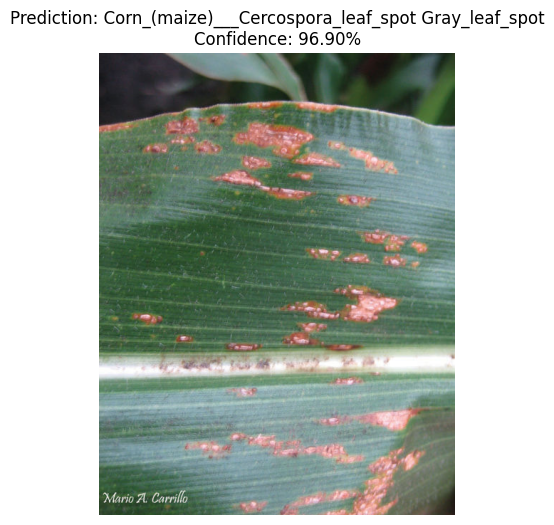


PREDICTION RESULT
Predicted Class : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Confidence      : 96.90%


In [32]:
# CELL 29 — Upload a Leaf Image for Prediction

from google.colab import files
import os

uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]

    print("Image uploaded successfully!")
    print("Image path:", image_path)

    # Run prediction
    predicted_class, confidence = predict(image_path)

    print("\n" + "=" * 70)
    print("PREDICTION RESULT")
    print("=" * 70)
    print("Predicted Class :", predicted_class)
    print("Confidence      :", f"{confidence * 100:.2f}%")

#Top-3 Disease Predictions

In [33]:
# CELL 30 — Top-3 Disease Predictions

import torch
import matplotlib.pyplot as plt
from PIL import Image


def predict_top3(image_path, top_k=3):
    """
    Predict the top-k most likely crop disease classes.

    Parameters:
        image_path (str): Path to input image
        top_k (int): Number of predictions to return

    Returns:
        List of (class_name, confidence) tuples
    """

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess image
    input_tensor = inference_transform(image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        outputs = inference_model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)

        top_probabilities, top_indices = torch.topk(
            probabilities, top_k, dim=1
        )

    # Display image
    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.title("AI Disease Prediction")
    plt.show()

    # Display results
    results = []

    print("=" * 70)
    print(f"TOP {top_k} PREDICTIONS")
    print("=" * 70)

    for rank in range(top_k):
        class_index = top_indices[0][rank].item()
        probability = top_probabilities[0][rank].item()

        class_name = inference_class_names[class_index]

        results.append((class_name, probability))

        print(
            f"{rank + 1}. {class_name:<55} "
            f"{probability * 100:.2f}%"
        )

    return results


print("Top-3 prediction function created successfully!")
print("Function: predict_top3(image_path)")

Top-3 prediction function created successfully!
Function: predict_top3(image_path)


In [34]:
predict_top3("download (2).jpg")

FileNotFoundError: [Errno 2] No such file or directory: 'download (2).jpg'

#Disease Information Database

In [35]:
# CELL 31 — Disease Information Database

disease_info = {

    "Apple___Apple_scab": {
        "crop": "Apple",
        "disease": "Apple Scab",
        "symptoms": "Dark olive or brown spots appearing on leaves and fruit.",
        "precautions": "Remove infected plant material, maintain good airflow, and avoid prolonged leaf wetness."
    },

    "Apple___Black_rot": {
        "crop": "Apple",
        "disease": "Apple Black Rot",
        "symptoms": "Dark circular lesions and blackened areas may appear on leaves, branches, or fruit.",
        "precautions": "Remove infected material, prune affected branches, and maintain orchard sanitation."
    },

    "Apple___Cedar_apple_rust": {
        "crop": "Apple",
        "disease": "Cedar Apple Rust",
        "symptoms": "Yellow-orange spots may appear on leaves, sometimes developing into larger lesions.",
        "precautions": "Remove infected plant material and improve airflow around plants."
    },

    "Apple___healthy": {
        "crop": "Apple",
        "disease": "Healthy",
        "symptoms": "No obvious disease symptoms detected.",
        "precautions": "Continue regular monitoring, proper nutrition, watering, and plant hygiene."
    },

    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": {
        "crop": "Corn",
        "disease": "Cercospora Leaf Spot / Gray Leaf Spot",
        "symptoms": "Gray to brown elongated lesions can develop on corn leaves.",
        "precautions": "Maintain field sanitation, improve airflow, and use appropriate crop management practices."
    },

    "Corn_(maize)___Common_rust_": {
        "crop": "Corn",
        "disease": "Common Rust",
        "symptoms": "Small reddish-brown rust-colored pustules may appear on leaves.",
        "precautions": "Monitor fields regularly and use appropriate resistant varieties and crop management practices."
    },

    "Corn_(maize)___Northern_Leaf_Blight": {
        "crop": "Corn",
        "disease": "Northern Leaf Blight",
        "symptoms": "Long gray-green or brown lesions may appear on leaves.",
        "precautions": "Remove infected crop residues where appropriate and use resistant varieties."
    },

    "Corn_(maize)___healthy": {
        "crop": "Corn",
        "disease": "Healthy",
        "symptoms": "No obvious disease symptoms detected.",
        "precautions": "Continue regular crop monitoring and maintain proper irrigation and nutrition."
    },

    "Grape___Black_rot": {
        "crop": "Grape",
        "disease": "Black Rot",
        "symptoms": "Brown or reddish leaf lesions and dark fruit infections may occur.",
        "precautions": "Remove infected plant material and improve canopy airflow."
    },

    "Grape___Esca_(Black_Measles)": {
        "crop": "Grape",
        "disease": "Esca / Black Measles",
        "symptoms": "Leaf discoloration and characteristic spotting can develop on grape leaves.",
        "precautions": "Remove severely affected plant material and maintain vineyard sanitation."
    },

    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": {
        "crop": "Grape",
        "disease": "Grape Leaf Blight",
        "symptoms": "Dark spots and lesions can develop on grape leaves.",
        "precautions": "Remove infected leaves and improve airflow through the canopy."
    },

    "Grape___healthy": {
        "crop": "Grape",
        "disease": "Healthy",
        "symptoms": "No obvious disease symptoms detected.",
        "precautions": "Continue regular monitoring and maintain good vineyard hygiene."
    },

    "Pepper,_bell___Bacterial_spot": {
        "crop": "Bell Pepper",
        "disease": "Bacterial Spot",
        "symptoms": "Small dark spots or lesions can appear on leaves and fruit.",
        "precautions": "Avoid unnecessary leaf wetness, remove infected material, and maintain plant hygiene."
    },

    "Pepper,_bell___healthy": {
        "crop": "Bell Pepper",
        "disease": "Healthy",
        "symptoms": "No obvious disease symptoms detected.",
        "precautions": "Continue regular monitoring and maintain proper watering and nutrition."
    },

    "Potato___Early_blight": {
        "crop": "Potato",
        "disease": "Early Blight",
        "symptoms": "Dark lesions with concentric ring patterns can develop on older leaves.",
        "precautions": "Remove infected plant material and maintain appropriate crop spacing and irrigation practices."
    },

    "Potato___Late_blight": {
        "crop": "Potato",
        "disease": "Late Blight",
        "symptoms": "Dark water-soaked lesions may rapidly develop on leaves.",
        "precautions": "Remove severely infected material and avoid prolonged leaf wetness."
    },

    "Potato___healthy": {
        "crop": "Potato",
        "disease": "Healthy",
        "symptoms": "No obvious disease symptoms detected.",
        "precautions": "Continue regular monitoring and maintain proper crop nutrition and irrigation."
    },

    "Tomato___Bacterial_spot": {
        "crop": "Tomato",
        "disease": "Bacterial Spot",
        "symptoms": "Small dark spots may develop on leaves, stems, and fruit.",
        "precautions": "Avoid overhead watering, remove infected material, and maintain good plant hygiene."
    },

    "Tomato___Early_blight": {
        "crop": "Tomato",
        "disease": "Early Blight",
        "symptoms": "Dark lesions with concentric rings may develop on older tomato leaves.",
        "precautions": "Remove infected leaves, improve airflow, and avoid prolonged leaf wetness."
    },

    "Tomato___Late_blight": {
        "crop": "Tomato",
        "disease": "Late Blight",
        "symptoms": "Dark water-soaked lesions can rapidly spread across leaves.",
        "precautions": "Remove severely infected material and reduce prolonged leaf moisture."
    },

    "Tomato___Leaf_Mold": {
        "crop": "Tomato",
        "disease": "Leaf Mold",
        "symptoms": "Yellowish patches may appear on the upper leaf surface with mold growth underneath.",
        "precautions": "Improve ventilation, reduce humidity, and avoid excessive leaf wetness."
    },

    "Tomato___Septoria_leaf_spot": {
        "crop": "Tomato",
        "disease": "Septoria Leaf Spot",
        "symptoms": "Small circular leaf spots with darker margins may develop.",
        "precautions": "Remove infected leaves and avoid splashing water onto foliage."
    },

    "Tomato___Spider_mites Two-spotted_spider_mite": {
        "crop": "Tomato",
        "disease": "Two-Spotted Spider Mites",
        "symptoms": "Fine stippling, yellowing, and possible webbing may appear on leaves.",
        "precautions": "Monitor plants regularly and use appropriate integrated pest management practices."
    },

    "Tomato___Target_Spot": {
        "crop": "Tomato",
        "disease": "Target Spot",
        "symptoms": "Circular brown lesions with concentric rings can appear on leaves.",
        "precautions": "Remove infected foliage, improve airflow, and reduce prolonged leaf wetness."
    },

    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": {
        "crop": "Tomato",
        "disease": "Tomato Yellow Leaf Curl Virus",
        "symptoms": "Leaf curling, yellowing, reduced leaf growth, and stunted plant development may occur.",
        "precautions": "Control whitefly vectors, remove severely infected plants where appropriate, and maintain field sanitation."
    },

    "Tomato___Tomato_mosaic_virus": {
        "crop": "Tomato",
        "disease": "Tomato Mosaic Virus",
        "symptoms": "Mottled light and dark green patterns, leaf distortion, and reduced plant growth may occur.",
        "precautions": "Remove infected plants where appropriate, sanitize tools, and avoid spreading plant sap between plants."
    },

    "Tomato___healthy": {
        "crop": "Tomato",
        "disease": "Healthy",
        "symptoms": "No obvious disease symptoms detected.",
        "precautions": "Continue regular monitoring and maintain proper watering, nutrition, and plant hygiene."
    }
}

print("Disease information database created successfully!")
print("Total classes:", len(disease_info))

Disease information database created successfully!
Total classes: 27


#Save Current Baseline Metrics

In [36]:
# CELL 31 — Save Current Baseline Metrics

baseline_metrics = {
    "model": "EfficientNet-B0",
    "dataset": "PlantVillage",
    "num_classes": len(class_names),
    "validation_images": len(val_df),
    "macro_f1": macro_f1,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall
}

print("=" * 70)
print("CURRENT BASELINE")
print("=" * 70)

for key, value in baseline_metrics.items():
    if isinstance(value, float):
        print(f"{key:<25}: {value:.4f}")
    else:
        print(f"{key:<25}: {value}")

print("\nBaseline saved in memory.")

CURRENT BASELINE
model                    : EfficientNet-B0
dataset                  : PlantVillage
num_classes              : 27
validation_images        : 6771
macro_f1                 : 0.9938
macro_precision          : 0.9948
macro_recall             : 0.9930

Baseline saved in memory.


In [37]:
# CELL 32 — Class Mapping for AgriSmart AI

class_mapping = {}

for cls in class_names:
    crop, disease = cls.split("___", 1)

    if disease.lower() == "healthy":
        status = "Healthy"
        display_disease = "Healthy"
    else:
        status = "Disease"
        display_disease = disease.replace("_", " ").strip()

    display_crop = crop.replace("_", " ").replace(",", "").replace("(maize)", "").strip()

    class_mapping[cls] = {
        "crop": display_crop,
        "disease": display_disease,
        "status": status
    }

print("Class Mapping Created")
print("=" * 70)

for cls, info in class_mapping.items():
    print(
        f"{cls} -> "
        f"Crop: {info['crop']} | "
        f"Disease: {info['disease']} | "
        f"Status: {info['status']}"
    )

print("\nTotal mapped classes:", len(class_mapping))

Class Mapping Created
Apple___Apple_scab -> Crop: Apple | Disease: Apple scab | Status: Disease
Apple___Black_rot -> Crop: Apple | Disease: Black rot | Status: Disease
Apple___Cedar_apple_rust -> Crop: Apple | Disease: Cedar apple rust | Status: Disease
Apple___healthy -> Crop: Apple | Disease: Healthy | Status: Healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Crop: Corn | Disease: Cercospora leaf spot Gray leaf spot | Status: Disease
Corn_(maize)___Common_rust_ -> Crop: Corn | Disease: Common rust | Status: Disease
Corn_(maize)___Northern_Leaf_Blight -> Crop: Corn | Disease: Northern Leaf Blight | Status: Disease
Corn_(maize)___healthy -> Crop: Corn | Disease: Healthy | Status: Healthy
Grape___Black_rot -> Crop: Grape | Disease: Black rot | Status: Disease
Grape___Esca_(Black_Measles) -> Crop: Grape | Disease: Esca (Black Measles) | Status: Disease
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) -> Crop: Grape | Disease: Leaf blight (Isariopsis Leaf Spot) | Status: Disease
Gra

In [38]:
# CELL 33 — Farmer-Friendly Prediction

def predict_farmer_friendly(image_path):

    # Get model prediction
    predicted_class, confidence = predict(image_path)

    # Convert confidence from fraction to percentage
    confidence_percent = confidence * 100

    # Get mapped information
    info = class_mapping[predicted_class]

    # Determine status
    if info["status"] == "Healthy":
        if confidence_percent >= 80:
            status = "Healthy"
        else:
            status = "Needs Review"

    else:
        if confidence_percent >= 80:
            status = "Disease Detected"
        else:
            status = "Needs Review"

    result = {
        "crop": info["crop"],
        "disease": info["disease"],
        "status": status,
        "confidence": confidence_percent,
        "raw_class": predicted_class
    }

    print("=" * 60)
    print("🌱 AgriSmart AI — Prediction Result")
    print("=" * 60)

    print(f"Crop       : {result['crop']}")
    print(f"Condition  : {result['disease']}")
    print(f"Status     : {result['status']}")
    print(f"Confidence : {result['confidence']:.2f}%")

    print("=" * 60)

    return result

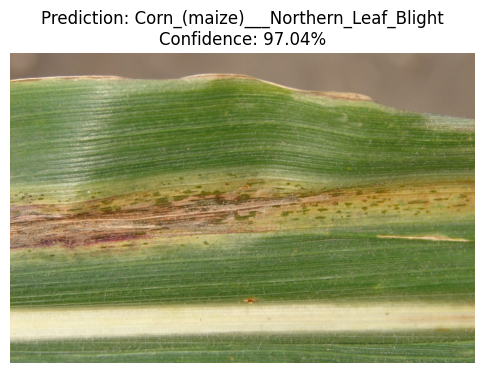

🌱 AgriSmart AI — Prediction Result
Crop       : Corn
Condition  : Northern Leaf Blight
Status     : Disease Detected
Confidence : 97.04%


In [39]:
result = predict_farmer_friendly("/content/corn2.jpg.jpeg")